# Notebook 02 — Dataset Construction and Exploration
### Super-Resolution as an Inverse Problem: Theory and Data Pipeline

This notebook walks through the construction and validation of the training dataset for the 
physics-informed super-resolution U-Net. It covers the mathematical foundations of the super-resolution 
problem, the information-theoretic limits of 4× upsampling, normalisation theory, class imbalance, 
physics-preserving augmentation, and visual inspection of the coarse/fine pairs.

---
| Item | Value |
|---|---|
| Total snapshots | 8909 |
| Re classes | 12 (Re=100 to Re=3200) |
| Channels | 4 — [u, v, p, ω] |
| Fine resolution | 64 × 64 |
| Coarse resolution | 16 × 16 (4× downsampled) |
| Augmentation | Physics-correct random flip |

## 0. Setup

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import glob
import torch
from collections import Counter
from scipy.ndimage import zoom
from data.dataset import (make_dataloaders, RE_VALUES, N_CLASSES,CHANNEL_NAMES, COARSE_SIZE, FINE_SIZE)
from data.augmentation import make_coarse_field, random_flip
PROJECT_ROOT = os.path.abspath('..')
SNAP_DIR   = os.path.join(PROJECT_ROOT, 'snapshots')
STATS_PATH = os.path.join(PROJECT_ROOT, 'train-data', 'stats.npy')

## 1. The Super-Resolution Problem — Mathematical Formulation

### 1.1 Forward and Inverse Problems

Let $\mathbf{f} \in \mathbb{R}^{C \times H \times W}$ denote a high-resolution (fine) flow field 
with $C=4$ channels and spatial resolution $H = W = 64$. The **forward problem** applies a 
deterministic downsampling operator $\mathcal{D}$:

$$\mathbf{c} = \mathcal{D}(\mathbf{f}) \in \mathbb{R}^{C \times h \times w}$$

where $h = w = 16$ (4× spatial downsampling in each dimension, $\mathcal{D}$ = block average).

The **super-resolution inverse problem** asks: given $\mathbf{c}$, recover $\mathbf{f}$.

This inverse problem is **ill-posed** in the sense of Hadamard (1902): the solution is **non-unique**. 
Infinitely many fine fields $\mathbf{f}$ can produce the same coarse field $\mathbf{c}$ under $\mathcal{D}$. 
The CNN learns to select a physically plausible solution by exploiting the statistical structure of 
cavity flow solutions — the ensemble of training snapshots implicitly defines a prior over plausible fine fields.

### 1.2 Information-Theoretic Limits of 4× Super-Resolution

The downsampling operator $\mathcal{D}$ (block averaging) is a **low-pass filter** in the spatial 
frequency domain. For a 4× downsampling ratio, the coarse field retains only Fourier modes with 
wavenumber $|k| \leq N/8 = 8$ (in each direction). All modes with $|k| > 8$ are **irreversibly lost**.

By the **Nyquist-Shannon sampling theorem**, a signal sampled at rate $f_s$ can represent frequencies 
up to $f_s/2$. On a 16×16 grid with physical spacing $\Delta x_c = L/16 = 0.0625$ m:

$$k_{\max}^{\text{coarse}} = \frac{N_c}{2} = 8 \text{ cycles per unit length}$$

This means any flow feature with length scale smaller than $2\Delta x_c = 0.125L$ is completely absent 
from the coarse input. The **boundary layer** in the lid-driven cavity has thickness $\delta \sim L/Re^{1/2}$:

| Re | $\delta/L$ | Resolved at 16×16? |
|---|---|---|
| 100 | 0.100 | Marginally (1.6 pixels) |
| 1000 | 0.032 | No (0.5 pixels) |
| 3200 | 0.018 | No (0.3 pixels) |

This analysis explains why the dominant reconstruction error is always concentrated at the right-wall 
boundary layer: it is a physically irrecoverable sub-pixel feature. The CNN can only **infer** its 
presence from the large-scale flow context, not directly observe it in the input.

### 1.3 Spatial Frequency Content

The total fraction of spatial frequency content retained by 4× downsampling is:

$$\text{Retained} = \left(\frac{N_c}{N_f}\right)^2 = \left(\frac{16}{64}\right)^2 = \frac{1}{16} = 6.25\%$$

In other words, **93.75% of the spatial frequency information is discarded** during downsampling. 
The CNN must learn to plausibly reconstruct this missing content from physical priors encoded in 
its weights — not from the input signal itself.

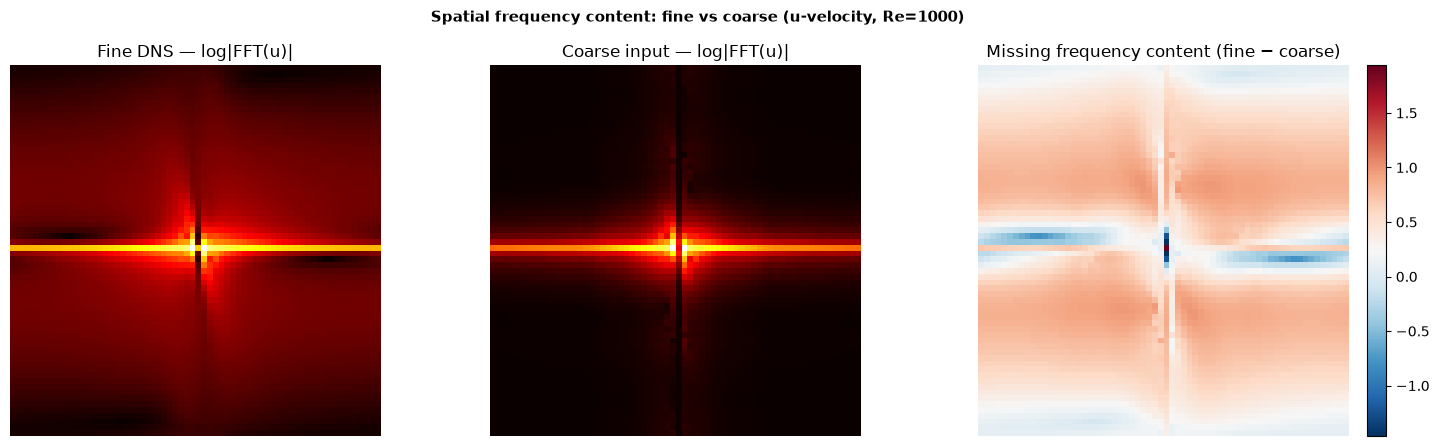

High-frequency content lost at 4x SR: 50.8%


In [2]:
snap_files = sorted(glob.glob(os.path.join(SNAP_DIR,'Re_1000/*.npy')))
snap = np.load(snap_files[0]).astype(np.float32)
u_fine = snap[0]
# Coarse: block average then upsample
factor = FINE_SIZE // COARSE_SIZE
u_small = u_fine.reshape(COARSE_SIZE,factor,COARSE_SIZE,factor).mean(axis=(1,3))
u_coarse = zoom(u_small, factor, order=1)
# FFT of both
F_fine   = np.abs(np.fft.fftshift(np.fft.fft2(u_fine)))
F_coarse = np.abs(np.fft.fftshift(np.fft.fft2(u_coarse)))
fig,axes = plt.subplots(1,3,figsize=(15,4.5))
fig.suptitle('Spatial frequency content: fine vs coarse (u-velocity, Re=1000)',fontsize=11,fontweight='bold')
axes[0].imshow(np.log1p(F_fine),cmap='hot',origin='lower')
axes[0].set_title('Fine DNS — log|FFT(u)|'); axes[0].axis('off')
axes[1].imshow(np.log1p(F_coarse),cmap='hot',origin='lower')
axes[1].set_title('Coarse input — log|FFT(u)|'); axes[1].axis('off')
# Difference
diff_f = np.log1p(F_fine) - np.log1p(F_coarse)
im=axes[2].imshow(diff_f,cmap='RdBu_r',origin='lower')
axes[2].set_title('Missing frequency content (fine − coarse)')
axes[2].axis('off')
plt.colorbar(im,ax=axes[2],fraction=0.046,pad=0.04)
plt.tight_layout()
plt.show()
print(f'High-frequency content lost at 4x SR: {100*(F_fine.sum()-F_coarse.sum())/F_fine.sum():.1f}%')

## 2. Normalisation Theory

### 2.1 Why Normalise?

The four channels of the flow field have vastly different physical scales:
- u-velocity: $\sigma_u \approx 0.190$ m/s
- v-velocity: $\sigma_v \approx 0.124$ m/s
- Pressure: $\sigma_p \approx 0.035$ Pa
- Vorticity: $\sigma_\omega \approx 3.38$ s⁻¹

Without normalisation, the **mean squared error loss** would be dominated by the channel with the 
largest variance. Specifically, the vorticity-to-pressure standard deviation ratio is 
$\sigma_\omega / \sigma_p \approx 97$, so the pressure MSE would contribute only 
$(1/97)^2 \approx 0.01\%$ of the total loss — effectively ignoring pressure entirely.

### 2.2 Z-Score Normalisation

Each channel $c$ is normalised independently using its dataset mean $\mu_c$ and standard deviation $\sigma_c$:

$$x_c^{\text{norm}} = \frac{x_c - \mu_c}{\sigma_c}$$

After normalisation, each channel has zero mean and unit variance over the training set. 
The reconstruction MSE in normalised space is then equally weighted across all channels (modulo the 
explicit channel weights $[w_u, w_v, w_p, w_\omega] = [3, 3, 2, 2]$ in the loss function).

### 2.3 Physical Interpretation of ω_mean < 0

The mean vorticity over the training dataset is $\mu_\omega = -0.857$ s⁻¹. This is **physically correct** 
and expected, not a data artefact. In the lid-driven cavity with the lid moving rightward (+x direction), 
the induced circulation is **clockwise** when viewed with y pointing upward. Clockwise rotation corresponds 
to **negative vorticity** ($\omega = \partial v/\partial x - \partial u/\partial y < 0$) in the standard 
right-handed coordinate system. The primary vortex fills most of the domain with negative vorticity, 
giving a negative domain average.

This is verified by the assertion `assert stats['mean'][3] < 0` in `dataset.py` — a solver that accidentally 
computes $\omega = \partial u/\partial y - \partial v/\partial x$ (wrong sign) would produce a positive mean 
and trigger this check.

Normalisation statistics:
  Channel               Mean        Std  Physical meaning
  u-velocity         +0.0117     0.1896
  v-velocity         +0.0023     0.1238
  pressure           -0.0000     0.0353
  vorticity ω        -0.8566     3.3839

w_mean/w_std = -0.253  (25% of 1 sigma — significant negative bias)
sigma_w/sigma_u     = 17.8x  (without normalisation, w MSE would be 319x larger than u MSE)


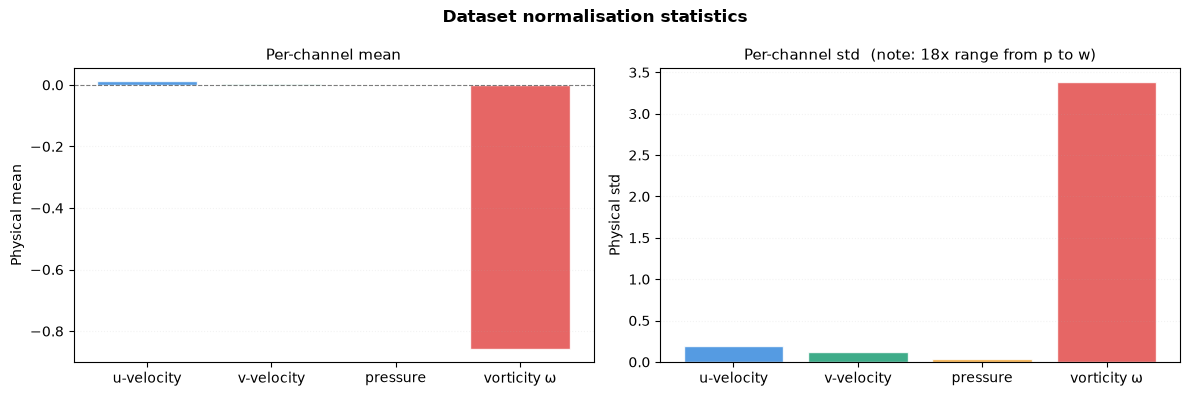

In [3]:
stats = np.load(STATS_PATH, allow_pickle=True).item()
mean, std = stats['mean'], stats['std']

print('Normalisation statistics:')
print(f'  {"Channel":<15} {"Mean":>10} {"Std":>10}  Physical meaning')
for i,name in enumerate(CHANNEL_NAMES):print(f'  {name:<15} {mean[i]:>+10.4f} {std[i]:>10.4f}')

print(f'\nw_mean/w_std = {mean[3]/std[3]:.3f}  (25% of 1 sigma — significant negative bias)')
print(f'sigma_w/sigma_u     = {std[3]/std[0]:.1f}x  (without normalisation, w MSE would be {(std[3]/std[0])**2:.0f}x larger than u MSE)')

fig,axes = plt.subplots(1,2,figsize=(12,4))
colors=['#378ADD','#1D9E75','#EF9F27','#E24B4A']
axes[0].bar(CHANNEL_NAMES,mean,color=colors,alpha=0.85,edgecolor='white')
axes[0].axhline(0,color='k',lw=0.8,ls='--',alpha=0.5)
axes[0].set_title('Per-channel mean',fontsize=11); axes[0].set_ylabel('Physical mean')
axes[0].grid(alpha=0.15,ls=':',axis='y')
axes[1].bar(CHANNEL_NAMES,std,color=colors,alpha=0.85,edgecolor='white')
axes[1].set_title('Per-channel std  (note: 18x range from p to w)',fontsize=11)
axes[1].set_ylabel('Physical std')
axes[1].grid(alpha=0.15,ls=':',axis='y')
fig.suptitle('Dataset normalisation statistics',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Class Distribution and Imbalance

### 3.1 Why Snapshot Counts Differ by Re

The snapshot count per Re class is determined by two factors:

1. **Solver runtime**: Simulations run until $t = t_{\text{end}} = \max(80, Re/8)$ seconds. 
Higher Re requires longer physical time to develop turbulent structures.
2. **Save frequency**: Snapshots are saved every $T_{\text{save}}$ seconds (Re-dependent). 
Low-Re flows converge early; high-Re flows continue saving until $t_{\text{end}}$.

The result is a **naturally imbalanced dataset**: Re=600 has ~1605 snapshots while Re=100 has only 150. 
This 10.7× imbalance would cause the classifier to ignore rare classes without mitigation.

### 3.2 Class-Weighted Cross-Entropy

The classifier loss uses **inverse-frequency weighting** to compensate for imbalance:

$$w_c = \frac{N_{\text{total}}}{C \cdot n_c}$$

where $N_{\text{total}}$ is the total number of training samples, $C=12$ is the number of classes, 
and $n_c$ is the count for class $c$. The weighted cross-entropy loss is:

$$\mathcal{L}_{\text{cls}} = -\sum_c w_c \cdot y_c \log(p_c)$$

This amplifies the gradient signal for rare classes (Re=100, 200) by a factor of $\sim 4.9\times$ 
relative to common classes (Re=600, 800), ensuring the classifier learns all 12 classes equally well. 
The result: **100% test classification accuracy** across all 12 Re classes despite 10.7× imbalance.

Imbalance: 1605/150 = 10.7x


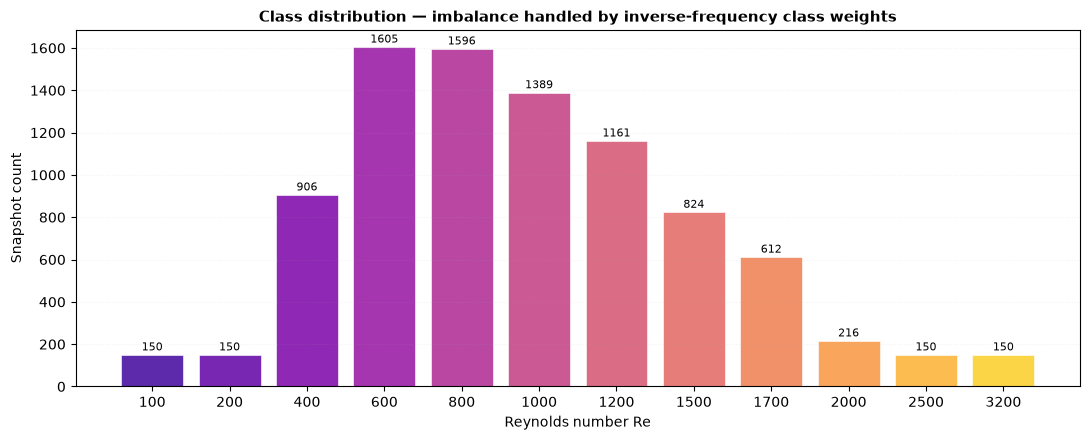

In [4]:
counts = {re: len(glob.glob(os.path.join(SNAP_DIR,f'Re_{re}/*.npy'))) for re in RE_VALUES}

fig,ax = plt.subplots(figsize=(11,4.5))
cmap_vals = plt.cm.plasma(np.linspace(0.1,0.9,len(RE_VALUES)))
bars = ax.bar([str(r) for r in RE_VALUES],[counts.get(r,0) for r in RE_VALUES],color=cmap_vals,alpha=0.85,edgecolor='white',linewidth=0.5)
for bar,re in zip(bars,RE_VALUES):
    n=counts.get(re,0)
    if n>0:ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+8,str(n),ha='center',va='bottom',fontsize=8)
ax.set_xlabel('Reynolds number Re'); ax.set_ylabel('Snapshot count')
ax.set_title('Class distribution — imbalance handled by inverse-frequency class weights',fontsize=11,fontweight='bold')
ax.grid(alpha=0.15,ls=':',axis='y')
max_re=max(counts,key=counts.get); min_re=min((r for r in counts if counts[r]>0),key=lambda r:counts[r])
print(f'Imbalance: {counts[max_re]}/{counts[min_re]} = {counts[max_re]/counts[min_re]:.1f}x')
plt.tight_layout()
plt.show()

## 4. Coarse / Fine Pair Generation

### 4.1 Downsampling Operator

The coarse field is generated by **block averaging** (spatial averaging): each $4\times4$ block of 
the 64×64 fine field is replaced by its mean value, yielding a 16×16 coarse field:

$$c_{i,j} = \frac{1}{16}\sum_{p=0}^{3}\sum_{q=0}^{3} f_{4i+p,\,4j+q}$$

This is equivalent to low-pass filtering followed by downsampling — it removes all spatial frequencies 
above the Nyquist frequency of the coarse grid ($k > N_c/2 = 8$).

### 4.2 Model Input Construction

The 16×16 coarse field is then **bilinearly upsampled** back to 64×64 to match the model's input shape:

$$\mathbf{x}_{\text{input}} = \text{bilinear-upsample}(c, \text{factor}=4)$$

This gives the model a 64×64 input where the spatial resolution has been artificially restored but 
the missing high-frequency content remains absent (smoothed out by the bilinear interpolation). 
The U-Net's task is to add back physically plausible high-frequency detail.

### 4.3 Gaussian Noise Injection

A small amount of Gaussian noise is added to training inputs only:

$$\mathbf{x}_{\text{noisy}} = \mathbf{x}_{\text{input}} + \boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$$

with $\sigma_{\text{noise}} = 0.05$ in normalised units. This prevents the CNN from overfitting to 
the exact algebraic relationship between the block-averaged coarse field and the upsampled input — 
forcing it to learn the statistical physics of the flow rather than the downsampling artefact pattern.

In [5]:
train_loader,val_loader,test_loader,stats,class_weights,_ = make_dataloaders(data_dir=SNAP_DIR, batch_size=16, seed=67,output_dir=os.path.join(PROJECT_ROOT,'train-data'))
train_ds = train_loader.dataset
re_names = {i:f'Re={re}' for i,re in enumerate(RE_VALUES)}

print(f'Train: {len(train_ds)} samples  Val: {len(val_loader.dataset)}  Test: {len(test_loader.dataset)}')
print(f'Class weights (inverse frequency):')
for i,(re,w) in enumerate(zip(RE_VALUES,class_weights)):
    print(f'  Re={re:5d}: w={w:.3f}')


Building dataset from: /home/kevin/Physics_Projects/Turbulence-cnn/snapshots
RNG seed: 67
  Re   100  label  0  snapshots  150
  Re  1000  label  5  snapshots 1389
  Re  1200  label  6  snapshots 1161
  Re  1500  label  7  snapshots  824
  Re  1700  label  8  snapshots  612
  Re   200  label  1  snapshots  150
  Re  2000  label  9  snapshots  216
  Re  2500  label 10  snapshots  150
  Re  3200  label 11  snapshots  150
  Re   400  label  2  snapshots  906
  Re   600  label  3  snapshots 1605
  Re   800  label  4  snapshots 1596

Total snapshots loaded: 8909
  ω_mean = -0.8566 (negative = clockwise = correct )

Normalisation statistics:
 [0] u-velocity       mean=+0.0117  std=0.1896
 [1] v-velocity       mean=+0.0023  std=0.1238
 [2] pressure         mean=-0.0000  std=0.0353
 [3] vorticity ω      mean=-0.8566  std=3.3839
 Saved  /home/kevin/Physics_Projects/Turbulence-cnn/train-data/stats.npy

Second pass — applying outlier filter...
  Re   100  label  0  snapshots  150
  Re  1000  lab

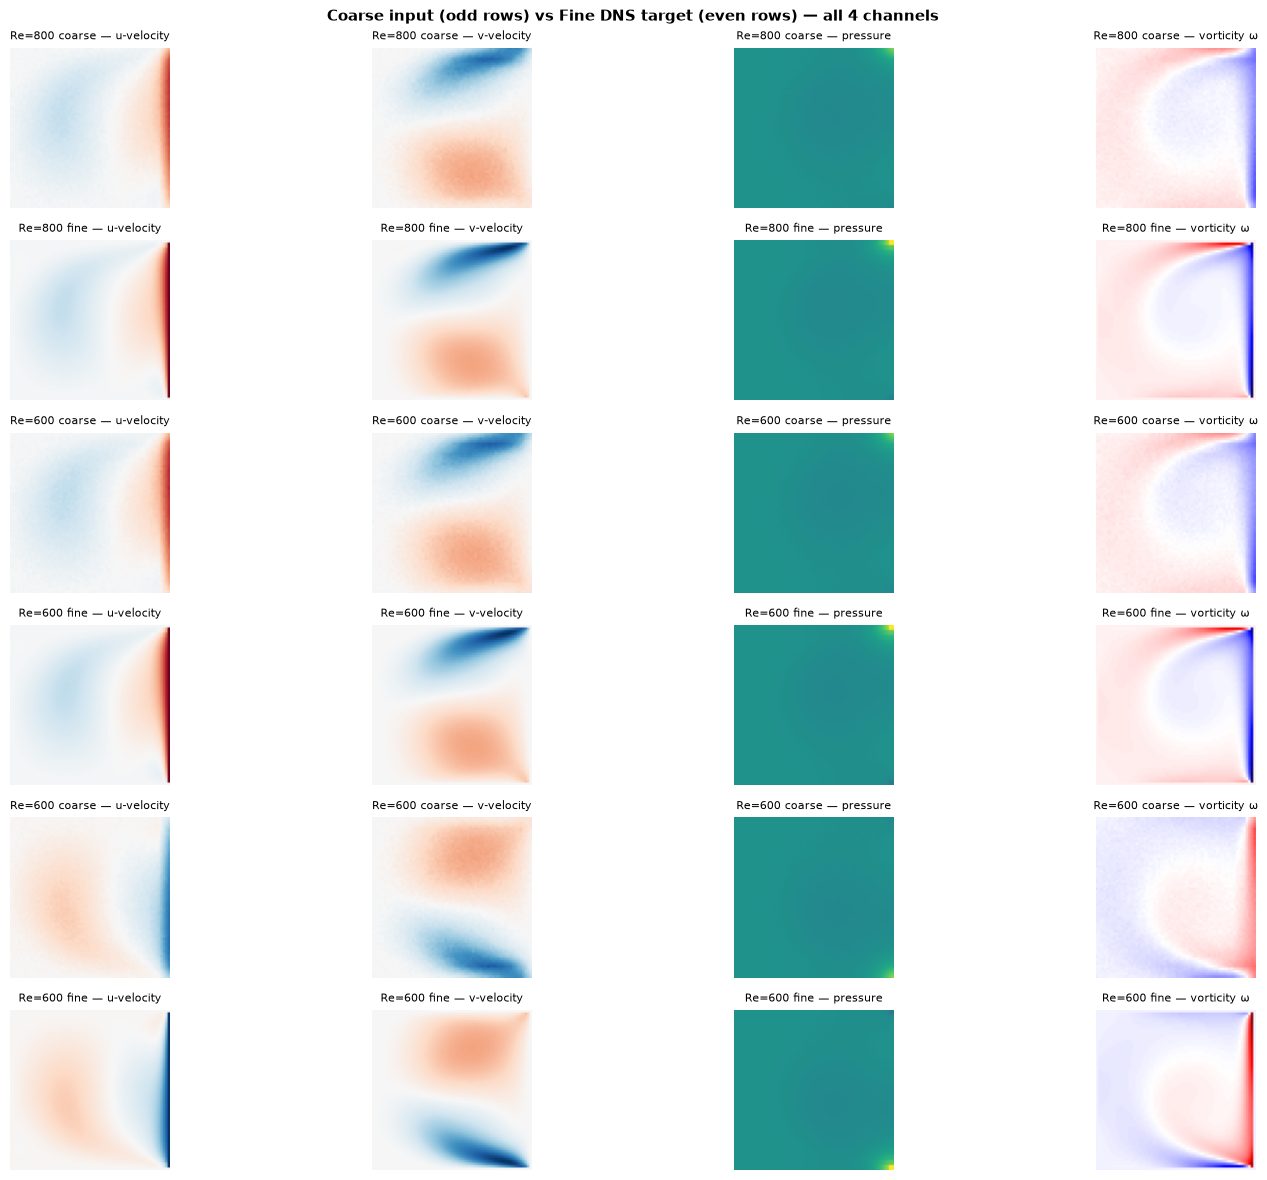

In [6]:
sample_indices = [0, len(train_ds)//3, 2*len(train_ds)//3]
fig,axes = plt.subplots(len(sample_indices)*2,4,figsize=(16,len(sample_indices)*4))
fig.suptitle('Coarse input (odd rows) vs Fine DNS target (even rows) — all 4 channels',fontsize=11,fontweight='bold')
cmaps=['RdBu_r','RdBu_r','viridis','seismic']
for row,idx in enumerate(sample_indices):
    coarse,fine,label = train_ds[idx]
    c_np=coarse.numpy()
    f_np=fine.numpy()
    re_str=re_names.get(label.item(),'?')
    for ch,(name,cmap) in enumerate(zip(CHANNEL_NAMES,cmaps)):
        vmax=max(np.abs(f_np[ch]).max(),1e-8)
        r0=row*2
        r1=row*2+1
        axes[r0,ch].imshow(c_np[ch],cmap=cmap,origin='lower',vmin=-vmax,vmax=vmax)
        axes[r0,ch].set_title(f'{re_str} coarse — {name}',fontsize=8); axes[r0,ch].axis('off')
        axes[r1,ch].imshow(f_np[ch],cmap=cmap,origin='lower',vmin=-vmax,vmax=vmax)
        axes[r1,ch].set_title(f'{re_str} fine — {name}',fontsize=8); axes[r1,ch].axis('off')
plt.tight_layout()
plt.show()

## 5. Missing Detail Analysis

The reconstruction target for the CNN is the pointwise difference $|\mathbf{f} - \mathcal{D}(\mathbf{f})|$, 
i.e., the information lost in downsampling. Visualising this map directly reveals where the CNN's 
reconstruction effort is focused.

**Expected pattern**: For lid-driven cavity flow, the missing detail is concentrated at the **right-wall 
boundary layer** — the thin shear layer where the no-slip right wall forces $u \to 0$ from the interior 
value $u \sim 0.5$–$0.8$. This layer has thickness $\delta \sim L/Re^{1/2}$ which is sub-pixel at $N_c=16$ 
for all Re values in the training set.

This spatial concentration has an important implication for metrics: the **rel_l2 = 16.9%** test error 
is dominated by this one narrow strip. The bulk flow reconstruction is far more accurate, but the L2 norm 
weights the high-amplitude boundary layer error heavily.

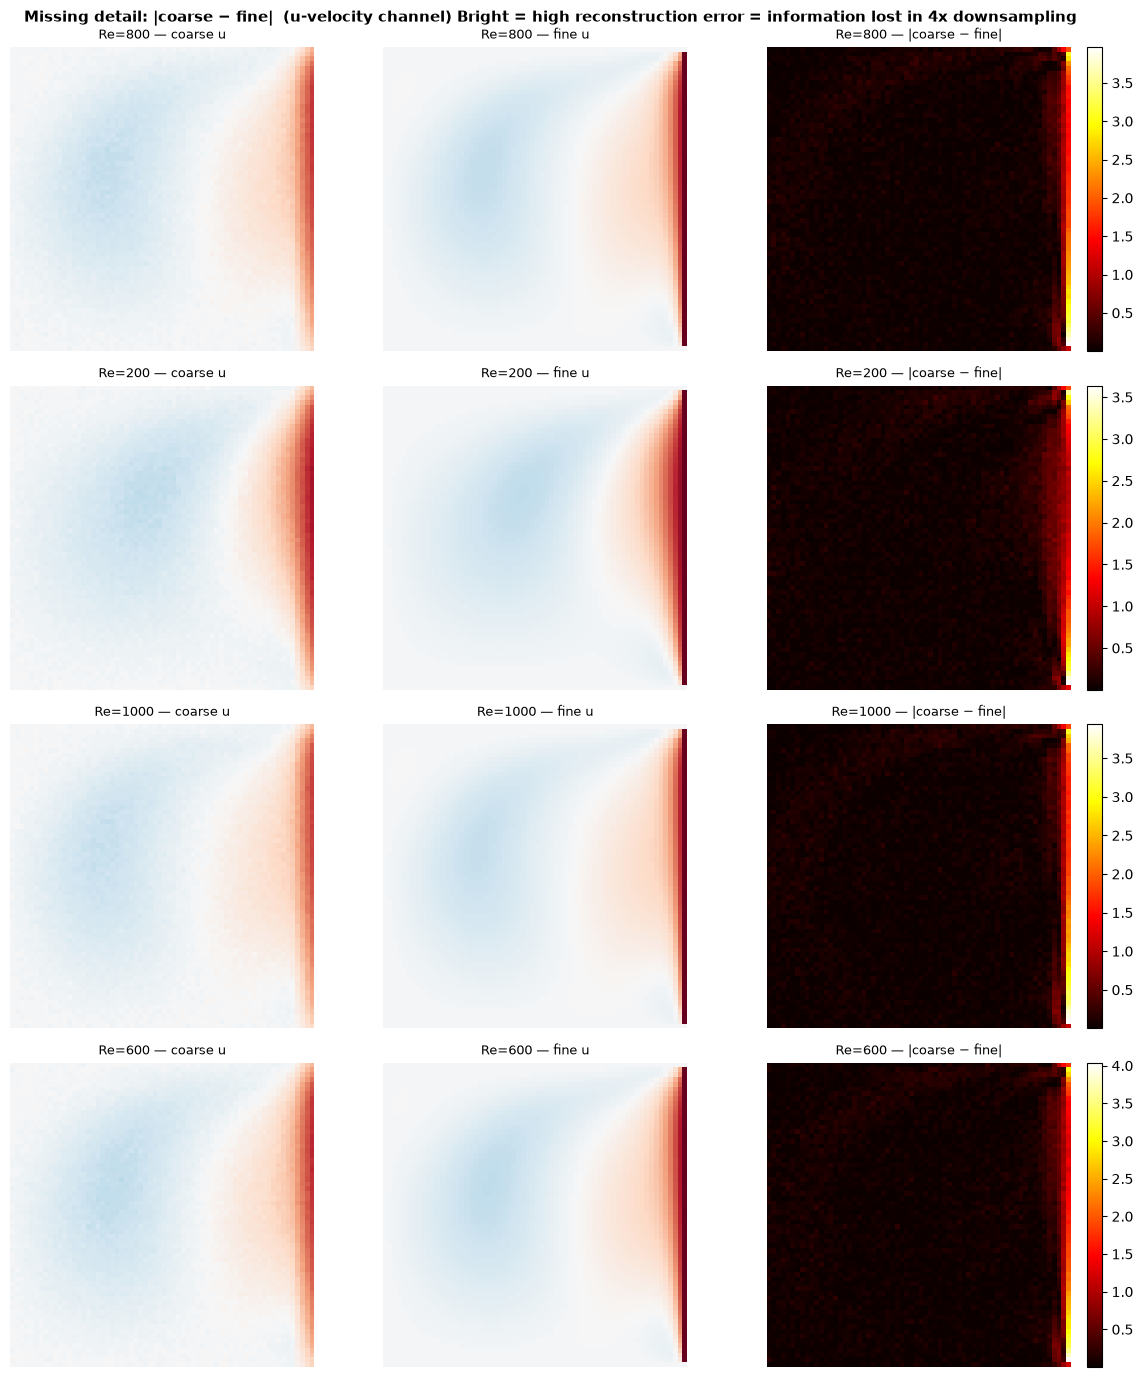

In [7]:
n_show=4
fig,axes=plt.subplots(n_show,3,figsize=(12,n_show*3.5))
fig.suptitle('Missing detail: |coarse − fine|  (u-velocity channel) Bright = high reconstruction error = information lost in 4x downsampling',fontsize=11,fontweight='bold')
for row in range(n_show):
    coarse,fine,label=train_ds[row*(len(train_ds)//(n_show+1))]
    c=coarse[0].numpy()
    f=fine[0].numpy()
    diff=np.abs(f-c)
    vmax=max(np.abs(f).max(),1e-8)
    re_str=re_names.get(label.item(),'?')
    axes[row,0].imshow(c,cmap='RdBu_r',origin='lower',vmin=-vmax,vmax=vmax)
    axes[row,0].set_title(f'{re_str} — coarse u',fontsize=9); axes[row,0].axis('off')
    axes[row,1].imshow(f,cmap='RdBu_r',origin='lower',vmin=-vmax,vmax=vmax)
    axes[row,1].set_title(f'{re_str} — fine u',fontsize=9); axes[row,1].axis('off')
    im=axes[row,2].imshow(diff,cmap='hot',origin='lower')
    axes[row,2].set_title(f'{re_str} — |coarse − fine|',fontsize=9); axes[row,2].axis('off')
    plt.colorbar(im,ax=axes[row,2],fraction=0.046,pad=0.04)
plt.tight_layout()
plt.show()

## 6. Physics-Preserving Data Augmentation

### 6.1 Why Standard Augmentation Breaks Physics

Standard image augmentations (random flip, rotate, crop) are valid for natural images because images 
have no intrinsic orientation. Velocity fields are different: they obey the Navier-Stokes equations, 
which are **not invariant** under arbitrary coordinate transforms.

For example, naively flipping the u-velocity field horizontally without changing its sign would produce 
a field where fluid flows in the wrong direction relative to the boundary conditions — a physically 
impossible configuration that would corrupt the training distribution.

### 6.2 Valid Symmetries of the Navier-Stokes Equations

The lid-driven cavity with a rightward-moving top lid has the following discrete symmetry:

**Left-right reflection** (x-flip, $x \to L-x$): Valid if we simultaneously reverse the lid direction. 
Under this transform, the new lid moves **leftward** — but since we only flip within a snapshot 
(treating the flipped field as a physically realised solution in a leftward-lid cavity), the signs must be corrected.

The sign correction rules follow directly from the definition of vorticity 
$\omega = \partial v/\partial x - \partial u/\partial y$ and the antisymmetry of each component:

**Under left-right flip** ($x \to -x$, i.e., axis=1 in array indexing):
$$u \to -u, \quad v \to +v, \quad p \to +p, \quad \omega \to -\omega$$

**Under top-bottom flip** ($y \to -y$, i.e., axis=2 in array indexing):
$$u \to +u, \quad v \to -v, \quad p \to +p, \quad \omega \to -\omega$$

**Derivation of the vorticity sign rule** for x-flip:
$$\omega' = \frac{\partial v'}{\partial x'} - \frac{\partial u'}{\partial y'} = \frac{\partial v}{\partial(-x)} - \frac{\partial(-u)}{\partial y} = -\frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} = -\omega$$

### 6.3 Effect on Training

Physics-correct augmentation effectively **doubles the training set size** without introducing any 
unphysical samples. The augmented samples are exact solutions of the Navier-Stokes equations 
(in a reflected geometry), so they provide genuinely new information about the statistical structure 
of cavity flow boundary layers and vortex structures.

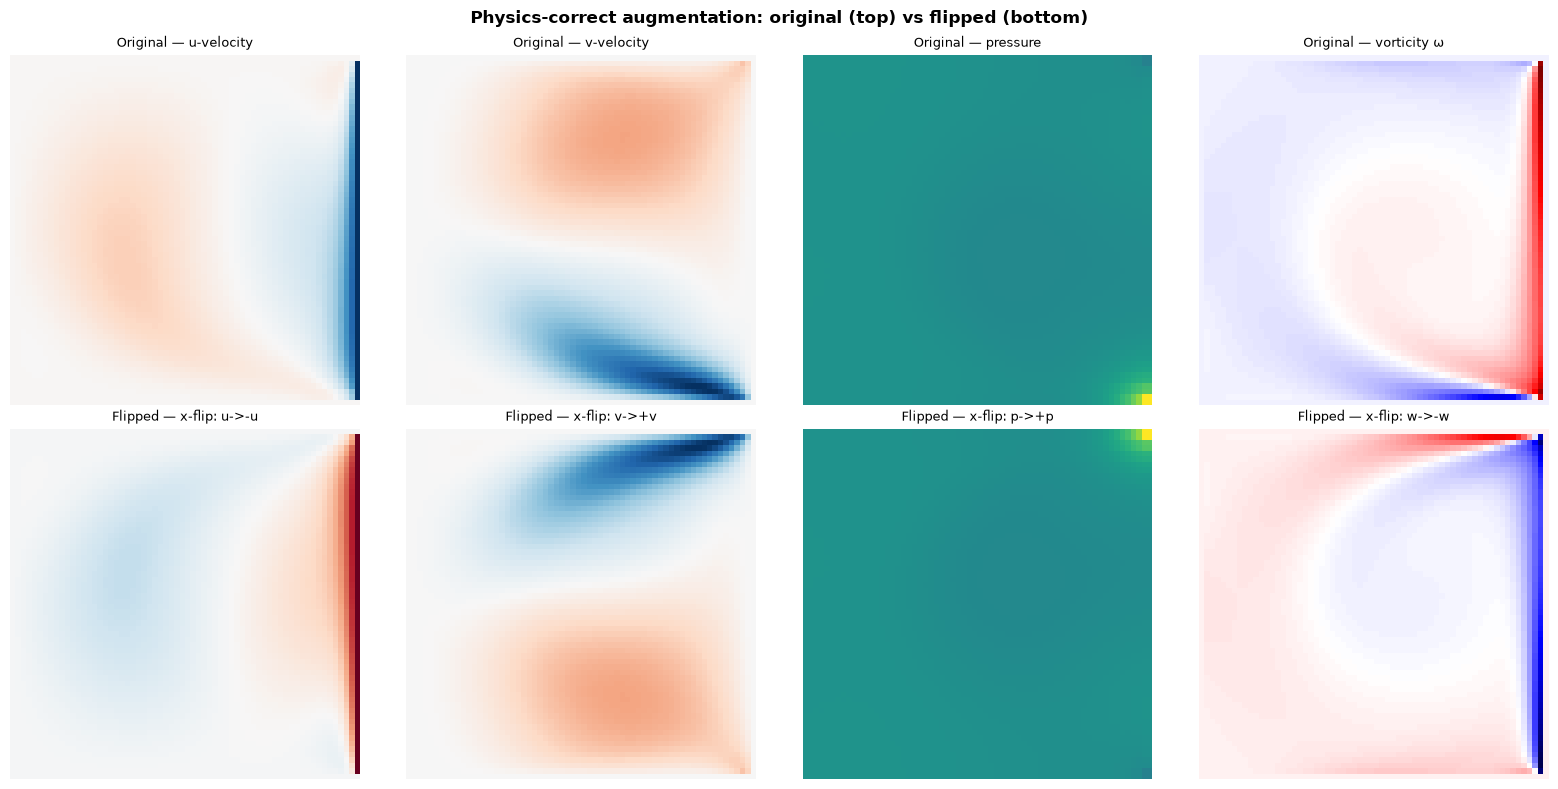

Sign rule verification:
  max(flipped_u + original_u) ≈ 0: 2.2303 (should be ~0 for pure x-flip)


In [9]:
coarse_s,fine_s,label_s = train_ds[0]
fine_np = fine_s.numpy()
flipped = random_flip(fine_np.copy())
fig,axes=plt.subplots(2,4,figsize=(16,8))
fig.suptitle('Physics-correct augmentation: original (top) vs flipped (bottom)',fontsize=12,fontweight='bold')
sign_rules=[('u -> -u (x-flip reverses streamwise vel.)','x-flip: u->-u'),
            ('v -> +v (normal vel. unchanged)','x-flip: v->+v'),
            ('p -> +p (scalar, unchanged)','x-flip: p->+p'),
            ('w -> -w (derived from sign rules)','x-flip: w->-w')]
cmaps=['RdBu_r','RdBu_r','viridis','seismic']
for ch,(name,rule) in enumerate(sign_rules):
    vmax=max(np.abs(fine_np[ch]).max(),1e-8)
    axes[0,ch].imshow(fine_np[ch],cmap=cmaps[ch],origin='lower',vmin=-vmax,vmax=vmax)
    axes[0,ch].set_title(f'Original — {CHANNEL_NAMES[ch]}',fontsize=9); axes[0,ch].axis('off')
    axes[1,ch].imshow(flipped[ch],cmap=cmaps[ch],origin='lower',vmin=-vmax,vmax=vmax)
    axes[1,ch].set_title(f'Flipped — {rule}',fontsize=9); axes[1,ch].axis('off')
plt.tight_layout()
plt.show()
print('Sign rule verification:')
print(f'  max(flipped_u + original_u) ≈ 0: {np.max(np.abs(flipped[0]+fine_np[0])):.4f} (should be ~0 for pure x-flip)')

## 7. Normalisation Sanity Check

After z-score normalisation, each channel should approximate a standard normal distribution $\mathcal{N}(0,1)$. 
Deviations indicate non-Gaussian structure in the physical fields:

- **u, v, p**: Expected to be approximately Gaussian (smooth fields, no extreme values)
- **vorticity ω**: Expected to have **heavy tails** due to boundary layer spikes. 
Near the right wall, $|\omega| \sim U/\delta \approx 1/(L/Re^{1/2}) = Re^{1/2}$ — at Re=3200 this gives 
$|\omega| \approx 57$ s⁻¹ = $57/3.38 \approx 17$ normalised units. 
The heavy tails confirm that the CNN must learn to reconstruct extreme boundary layer values, 
not just the bulk flow statistics.

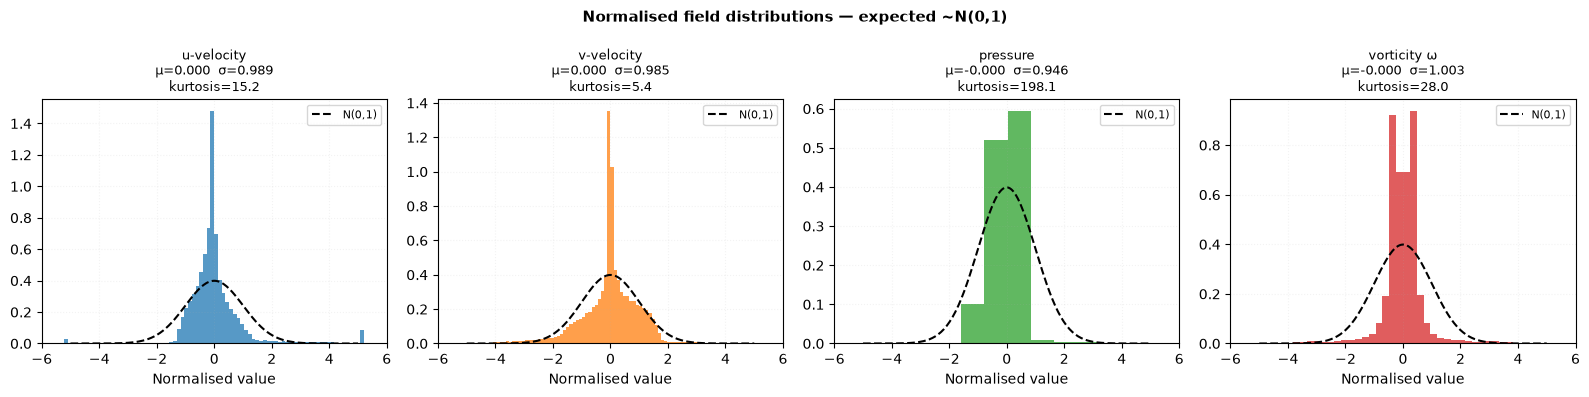

Kurtosis > 3 = heavier tails than Gaussian (expected for vorticity)


In [10]:
all_fine=[]
for i in range(0,min(300,len(train_ds)),1):
    _,fine,_ = train_ds[i]
    all_fine.append(fine.numpy())
all_fine=np.stack(all_fine)
fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('Normalised field distributions — expected ~N(0,1)',fontsize=11,fontweight='bold')
x_r=np.linspace(-5,5,200)
gaussian=np.exp(-x_r**2/2)/np.sqrt(2*np.pi)
for ch,(ax,name) in enumerate(zip(axes,CHANNEL_NAMES)):
    vals=all_fine[:,ch].flatten()
    ax.hist(vals,bins=80,density=True,alpha=0.75,color=f'C{ch}',edgecolor='none')
    ax.plot(x_r,gaussian,'k--',lw=1.5,label='N(0,1)')
    kurtosis=(np.mean((vals-vals.mean())**4)/vals.std()**4)
    ax.set_title(f'{name}\nμ={vals.mean():.3f}  σ={vals.std():.3f}\nkurtosis={kurtosis:.1f}',fontsize=9)
    ax.set_xlabel('Normalised value'); ax.set_xlim(-6,6)
    ax.legend(fontsize=8); ax.grid(alpha=0.15,ls=':')
plt.tight_layout()
plt.show()
print('Kurtosis > 3 = heavier tails than Gaussian (expected for vorticity)')

---
## Summary

| Topic | Key insight |
|---|---|
| SR as inverse problem | Ill-posed: infinitely many fine fields produce the same coarse field |
| Information loss | 93.75% of spatial frequencies discarded at 4× downsampling |
| Boundary layer | Sub-pixel at all Re — physically unrecoverable from 16×16 input |
| ω_mean < 0 | Clockwise primary vortex — physically required, not a data error |
| Normalisation | 18× std ratio between ω and p — normalisation is essential |
| Class imbalance | 10.7× — corrected by inverse-frequency class weights |
| Augmentation | Physics-correct sign rules: x-flip → (u,v,p,ω) → (−u,+v,+p,−ω) |